In [18]:
# Cell 1 — imports
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sys

import os
os.makedirs('../results', exist_ok=True)

sys.path.append('..')

# Dataset is already QC'd and filtered, so we can skip those steps. Start with normalization and clustering.
from src.preprocess import run_normalization, save_checkpoint, load_checkpoint
from src.cluster import run_clustering_pipeline
from src.visualize import plot_umap
from src.annotate import score_gene_set, export_marker_table, find_marker_genes

sc.settings.verbosity = 3
sc.settings.figdir = '../results/'

In [26]:
# Cell 2 - Load Data
adata = sc.read_h5ad('../data/SEAAD_microglia.h5ad')
print("Microglia dataset loaded") 
print(adata)

metadata = pd.read_excel('../data/SEAAD_donor_metadata.xlsx')
print("Clinical columns:")
print(metadata.columns.tolist())

neuropath = pd.read_csv('../data/SEAAD_neuropathology.csv')
print("Neuropathology columns:")
print(neuropath.columns.tolist())

print("\n--- donor ID column in adata.obs ---")
donor_cols = [c for c in adata.obs.columns if any(x in c.lower() for x in ['donor', 'external', 'specimen'])]
print(donor_cols)
print(adata.obs[donor_cols].head(5))

Microglia dataset loaded
AnnData object with n_obs × n_vars = 240651 × 36601
    obs: 'sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Inter

In [20]:
# Cell 3 - Inspecting Clinical Variables

key_clinical = [
    'Cognitive Status',
    'Braak', 
    'CERAD score',
    'Overall AD neuropathology change',
    'Thal', 
    'APOE genotype',
    'Severely Affected Donor',
    'Sex',
    'Age at Death'
]

for col in key_clinical:
    if col in adata.obs.columns:
        print(f"\n{col}:")
        print(adata.obs[col].value_counts())
    else:
        print(f"\n{col}: NOT FOUND")


Cognitive Status:
Cognitive Status
No dementia    121506
Dementia       119145
Name: count, dtype: int64

Braak:
Braak
Braak V      90805
Braak IV     59138
Braak VI     48516
Braak III    17893
Braak II     17536
Braak 0       6763
Name: count, dtype: int64

CERAD score:
CERAD score
Moderate    84540
Frequent    82094
Absent      45988
Sparse      28029
Name: count, dtype: int64

Overall AD neuropathology change: NOT FOUND

Thal:
Thal
Thal 4    85565
Thal 5    59597
Thal 3    29986
Thal 2    23599
Thal 0    23132
Thal 1    18772
Name: count, dtype: int64

APOE genotype: NOT FOUND

Severely Affected Donor:
Severely Affected Donor
N    216446
Y     24205
Name: count, dtype: int64

Sex:
Sex
Female    138684
Male      101967
Name: count, dtype: int64

Age at Death:
Age at Death
94.0     24736
93.0     18264
98.0     16639
92.0     14738
88.0     13169
91.0     12903
81.0     11046
82.0     10631
99.0     10353
97.0      9243
89.0      8491
87.0      8366
75.0      8168
80.0      7949
90.

In [21]:
# Cell 4 - Inspect Existing Cell Type Annotations

print("Subclass labels:")
print(adata.obs['Subclass'].value_counts())

print("\nSupertype labels:")
print(adata.obs['Supertype'].value_counts())

print("\nClass labels:")
print(adata.obs['Class'].value_counts())

Subclass labels:
Subclass
Microglia-PVM    240651
Name: count, dtype: int64

Supertype labels:
Supertype
Micro-PVM_2            141248
Micro-PVM_2_3-SEAAD     53815
Micro-PVM_3-SEAAD       29805
Micro-PVM_1              7909
Lymphocyte               4607
Micro-PVM_4-SEAAD        1767
Micro-PVM_2_1-SEAAD      1458
Monocyte                   42
Name: count, dtype: int64

Class labels:
Class
Non-neuronal and Non-neural    240651
Name: count, dtype: int64


In [22]:
# Cell 5 - Check normalization status of adata.X and layers['UMIs']

# find genes with nonzero expression and sample those
nonzero_genes = np.where(np.array(adata.X.sum(axis=0)).flatten() > 0)[0][:5]

print("Normalized values (adata.X) for expressed genes:")
print(adata.X[:3, nonzero_genes].toarray())

print("\nRaw UMI counts for same genes:")
print(adata.layers['UMIs'][:3, nonzero_genes].toarray())

print("\nuns keys (log1p key = already normalized):")
print(list(adata.uns.keys()))

# diagnostic 1: check matrix stats
x_dense = adata.X[:100, :100].toarray()
print("Diagnostic 1")
print("Min:", x_dense.min())
print("Max:", x_dense.max())
print("Nonzero count:", np.count_nonzero(x_dense))
print("Total elements:", x_dense.size)

# d2: check matrix type and shape
print("Diagnostic 2")
print(type(adata.X))
print(adata.X.dtype)
print("Shape (cells x genes):", adata.shape)

# d3: check known microglial markers directly 

marker_genes = ['TREM2', 'P2RY12', 'CX3CR1', 'CSF1R', 'TMEM119']
print("Diagnostic 3")
for gene in marker_genes:
    if gene in adata.var_names:
        idx = list(adata.var_names).index(gene)
        vals = adata.X[:5, idx].toarray().flatten()
        print(f"{gene}: {vals}")
    else:
        print(f"{gene}: NOT FOUND in var_names")

#d4: check var_names
print("Diagnostic 4")
print("First 20 gene names:")
print(adata.var_names[:20].tolist())

print("\nTotal genes:", len(adata.var_names))

# Confirmed log-normalized. log1p floats + log1p in uns

Normalized values (adata.X) for expressed genes:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Raw UMI counts for same genes:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

uns keys (log1p key = already normalized):
['Subclass_colors', 'Supertype_colors', 'log1p', 'neighbors', 'umap']
Diagnostic 1
Min: 0.0
Max: 5.067644413153379
Nonzero count: 574
Total elements: 10000
Diagnostic 2
<class 'scipy.sparse._csr.csr_matrix'>
float64
Shape (cells x genes): (240651, 36601)
Diagnostic 3
TREM2: [2.12983138 0.         0.         0.         0.        ]
P2RY12: [3.42275637 4.31034787 4.34477318 3.95826411 4.84000919]
CX3CR1: [3.96829248 4.71132664 4.34477318 0.         0.        ]
CSF1R: [4.41337907 4.99675797 4.06140659 4.28926534 4.43848978]
TMEM119: [0.         0.         0.         0.         3.08702313]
Diagnostic 4
First 20 gene names:
['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3', 'AL627309.2', 'AL627309.5', 'AL627309.4', 'AP006222.2', 'AL732372.1', 'OR4F

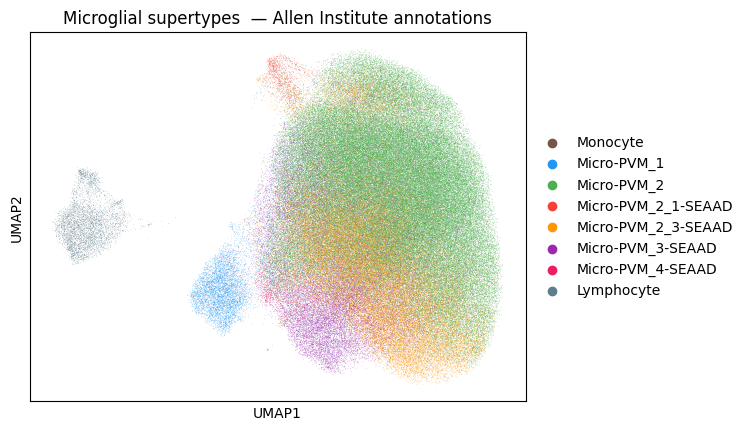

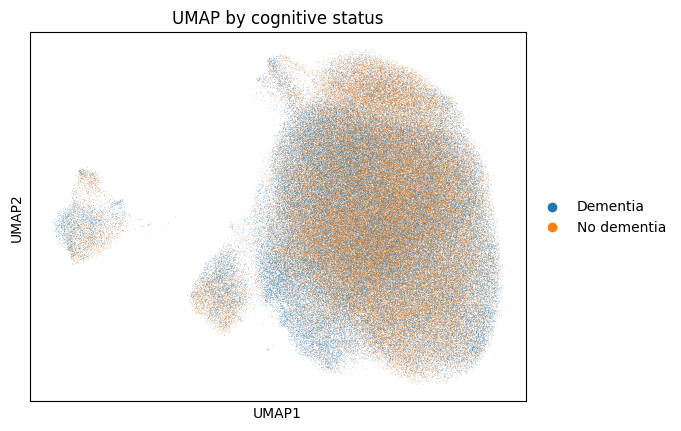

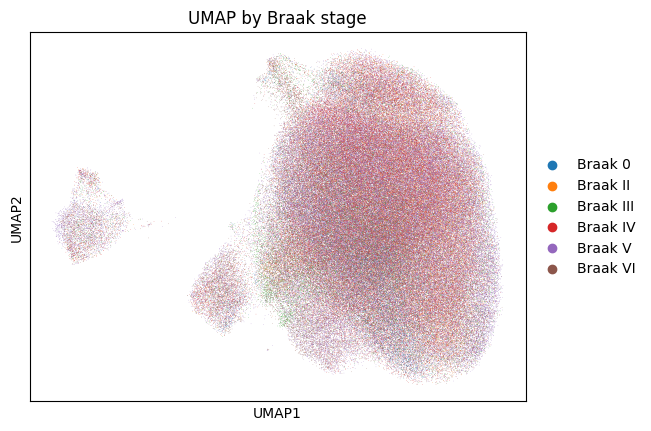

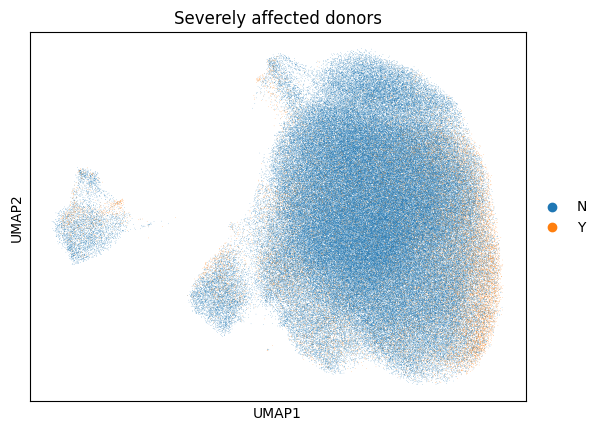

In [35]:
# Cell 6 - Visualize existing UMAP embeddings colored by clinical variables

# fix supertype colors
supertypes = adata.obs['Supertype'].cat.categories.tolist()
color_map = {
    'Micro-PVM_1':         '#2196F3',  # blue
    'Micro-PVM_2':         '#4CAF50',  # green
    'Micro-PVM_2_1-SEAAD': '#F44336',  # red
    'Micro-PVM_2_3-SEAAD': '#FF9800',  # orange
    'Micro-PVM_3-SEAAD':   '#9C27B0',  # purple
    'Micro-PVM_4-SEAAD':   '#E91E63',  # pink
    'Monocyte':            '#795548',  # brown
    'Lymphocyte':          '#607D8B',  # grey
}
adata.uns['Supertype_colors'] = [color_map.get(s, '#333333') for s in supertypes]

# color by cell supertype — Allen Institute annotations
sc.pl.umap(adata, color='Supertype',
           title='Microglial supertypes  — Allen Institute annotations',
           save = '_supertype.png')


# color by cognitive status — disease grouping
sc.pl.umap(adata, color='Cognitive Status',
           title='UMAP by cognitive status',
           save = '_cognitive_status.png')

# color by Braak stage — continuous disease severity
sc.pl.umap(adata, color='Braak',
           title='UMAP by Braak stage',
           color_map='RdYlBu_r',
            save = '_braak_stage.png')

# color by severely affected donor flag
sc.pl.umap(adata, color='Severely Affected Donor',
           title='Severely affected donors',
           save = '_severely_affected_donor.png')

In [28]:
# Cell 7 - Merge Neuropathology and Clinical Metadata

# Step 1: only keep meta columns that aren't already in adata.obs
meta_cols = [
    'Donor ID', 'Braak', 'CERAD score', 'Thal',
    'Overall AD neuropathological Change', 'APOE Genotype',
    'Age at Death', 'Sex', 'PMI', 'Last MMSE Score', 'LATE'
]

# filter to only new columns
new_meta_cols = ['Donor ID'] + [c for c in meta_cols[1:] 
                                 if c not in adata.obs.columns]
print("Meta cols to merge:", new_meta_cols)

# Step 2: neuropath columns
neuropath_cols = [
    'Donor ID',
    'percent Iba1 positive area_Grey matter',
    'number of activated Iba1 positive cells_Grey matter',
    'number of inactivated Iba1 positive cells_Grey matter',
    'number of Iba1 positive cells per area_Grey matter',
    'average Iba1 positive process length per cell_Grey matter',
    'percent AT8 positive area_Grey matter',
    'number of AT8 positive cells per area_Grey matter',
    'percent 6e10 positive area_Grey matter',
    'number of NeuN positive cells per area_Grey matter',
    'percent pTDP43 positive area_Grey matter',
    'ripa abeta42_Grey matter',
    'ripa pTau_Grey matter',
]

new_neuropath_cols = ['Donor ID'] + [c for c in neuropath_cols[1:] 
                                      if c not in adata.obs.columns]
print("Neuropath cols to merge:", new_neuropath_cols)

# Step 3: merge only new columns
if len(new_meta_cols) > 1:
    meta_slim = metadata[new_meta_cols].set_index('Donor ID')
    adata.obs = adata.obs.join(meta_slim, on='Donor ID')

neuropath_slim = neuropath[new_neuropath_cols].set_index('Donor ID')
adata.obs = adata.obs.join(neuropath_slim, on='Donor ID')

# Step 4: verify
print("\nSample merged values:")
check_cols = ['Donor ID', 'Braak', 'CERAD score', 
              'percent Iba1 positive area_Grey matter']
# only print cols that exist
check_cols = [c for c in check_cols if c in adata.obs.columns]
print(adata.obs[check_cols].head(5))

print("\nMissing values:")
print(adata.obs[check_cols].isnull().sum())

Meta cols to merge: ['Donor ID']
Neuropath cols to merge: ['Donor ID', 'percent Iba1 positive area_Grey matter', 'number of activated Iba1 positive cells_Grey matter', 'number of inactivated Iba1 positive cells_Grey matter', 'number of Iba1 positive cells per area_Grey matter', 'average Iba1 positive process length per cell_Grey matter', 'percent AT8 positive area_Grey matter', 'number of AT8 positive cells per area_Grey matter', 'percent 6e10 positive area_Grey matter', 'number of NeuN positive cells per area_Grey matter', 'percent pTDP43 positive area_Grey matter', 'ripa abeta42_Grey matter', 'ripa pTau_Grey matter']

Sample merged values:
                                                  Donor ID    Braak  \
exp_component_name                                                    
AAAGAACTCCAACACA-L8HX_230330_23_E03-1266294882  H21.33.036  Braak V   
AACAACCTCTATTTCG-L8HX_230330_23_E03-1266294882  H21.33.036  Braak V   
AACCATGCACGGGTAA-L8HX_230330_23_E03-1266294882  H21.33.036  Braak 

DAM genes found: ['TREM2', 'AXL', 'CST7', 'LPL', 'LGALS3', 'SPP1', 'TYROBP', 'CTSD', 'APOE', 'B2M']
Homeostatic genes found: ['P2RY12', 'CX3CR1', 'TMEM119', 'SALL1', 'CSF1R', 'SELPLG', 'HEXB']
computing score 'DAM_score'
    finished: added
    'DAM_score', score of gene set (adata.obs).
    299 total control genes are used. (0:00:14)
computing score 'Homeostatic_score'
    finished: added
    'Homeostatic_score', score of gene set (adata.obs).
    150 total control genes are used. (0:00:13)


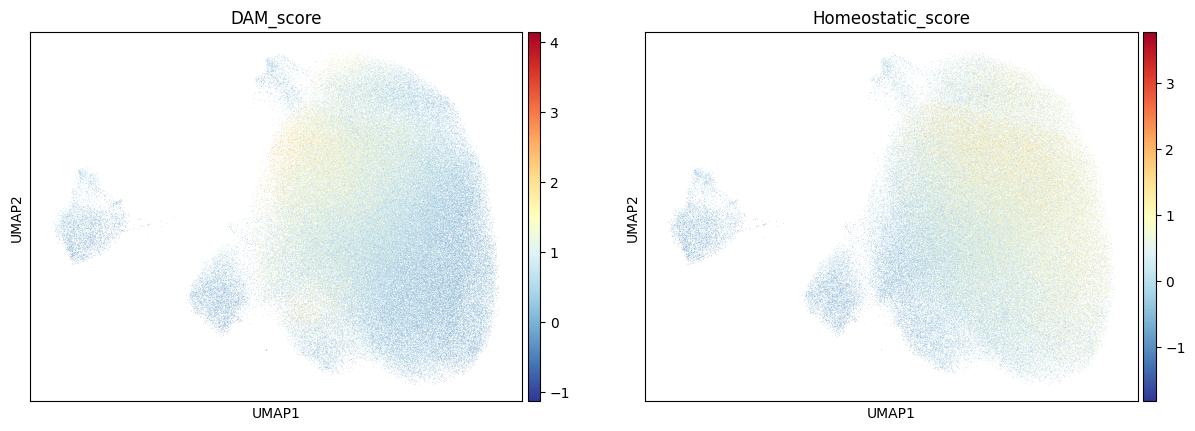

In [ ]:
# Cell 8 - Gene Set Scoring

# DAM signature - Keren-Shaul et al. 2017
dam_genes = ['TREM2', 'AXL', 'CST7', 'LPL', 'LGALS3', 
             'SPP1', 'TYROBP', 'CTSD', 'APOE', 'B2M']

# Homeostatic signature
homeostatic_genes = ['P2RY12', 'CX3CR1', 'TMEM119', 
                     'SALL1', 'CSF1R', 'SELPLG', 'HEXB']

# filter to genes actually in your dataset
dam_genes = [g for g in dam_genes if g in adata.var_names]
homeostatic_genes = [g for g in homeostatic_genes if g in adata.var_names]

print("DAM genes found:", dam_genes)
print("Homeostatic genes found:", homeostatic_genes)

# score each cell
sc.tl.score_genes(adata, dam_genes, score_name='DAM_score')
sc.tl.score_genes(adata, homeostatic_genes, score_name='Homeostatic_score')

# visualize on UMAP
sc.pl.umap(adata, color=['DAM_score', 'Homeostatic_score'],
           color_map='RdYlBu_r', show=False)
plt.savefig('../results/umap_gene_scores.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

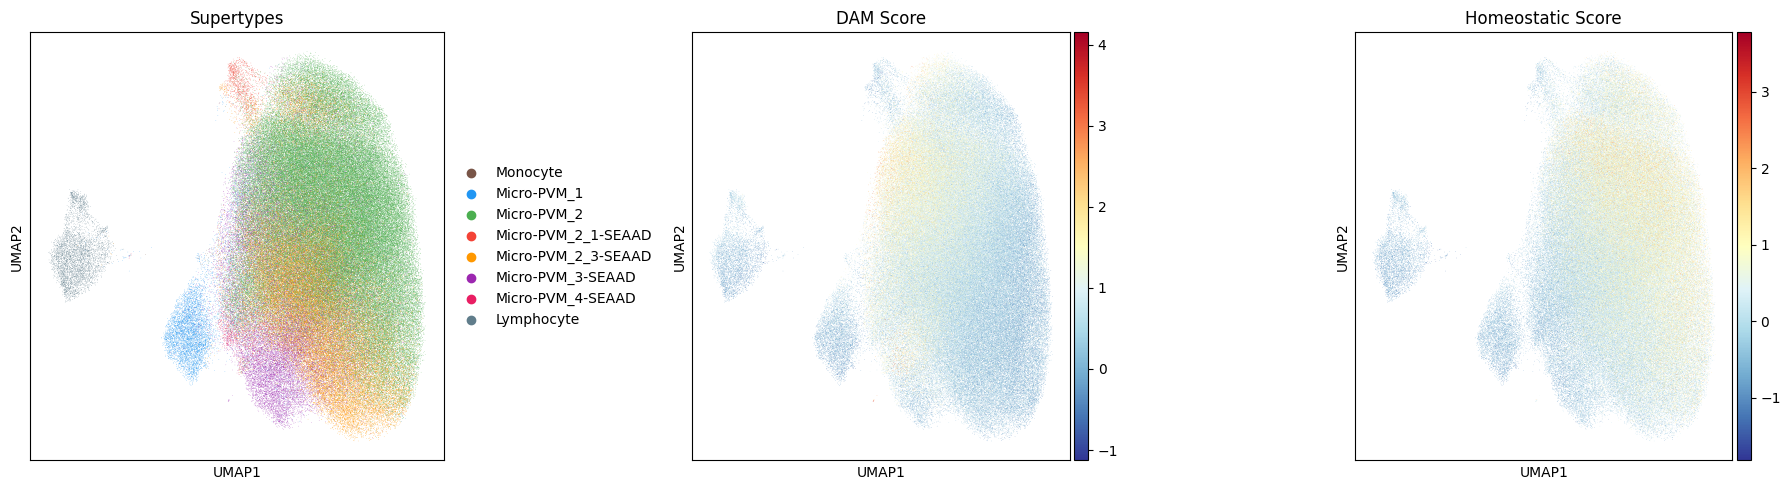

In [36]:
# Cell 8B: compare supertype locations to DAM score zones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc.pl.umap(adata, color='Supertype', title='Supertypes', 
           show=False, ax=axes[0])
sc.pl.umap(adata, color='DAM_score', color_map='RdYlBu_r',
           title='DAM Score', show=False, ax=axes[1])
sc.pl.umap(adata, color='Homeostatic_score', color_map='RdYlBu_r',
           title='Homeostatic Score', show=False, ax=axes[2])

plt.tight_layout()
plt.savefig('../results/umap_supertype_vs_scores.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

In [ ]:
# Cell 8C - UMAP Zone Analysis: Supertype Enrichment in High-DAM vs High-Homeostatic Regions

from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

# ── 1. Label each cell by UMAP zone (top-quartile thresholds) ───────────────
dam_thresh   = adata.obs['DAM_score'].quantile(0.75)
homeo_thresh = adata.obs['Homeostatic_score'].quantile(0.75)

high_dam   = adata.obs['DAM_score']   >= dam_thresh
high_homeo = adata.obs['Homeostatic_score'] >= homeo_thresh

zone = pd.Series('Intermediate', index=adata.obs.index)
zone[high_homeo]            = 'High-Homeostatic'
zone[high_dam]              = 'High-DAM'
zone[high_dam & high_homeo] = 'Mixed'

adata.obs['UMAP_zone'] = zone.astype('category')

print("Zone counts:")
print(adata.obs['UMAP_zone'].value_counts())
print(f"\nDAM threshold (75th pct):   {dam_thresh:.3f}")
print(f"Homeo threshold (75th pct): {homeo_thresh:.3f}")

# ── 2. Side-by-side UMAP: zones vs supertypes ───────────────────────────────
zone_palette = {
    'High-DAM':         '#E53935',
    'High-Homeostatic': '#1E88E5',
    'Mixed':            '#8E24AA',
    'Intermediate':     '#BDBDBD',
}
adata.uns['UMAP_zone_colors'] = [
    zone_palette[z] for z in adata.obs['UMAP_zone'].cat.categories
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(adata, color='UMAP_zone', title='UMAP zones', show=False, ax=axes[0])
sc.pl.umap(adata, color='Supertype',  title='Supertypes',  show=False, ax=axes[1])
plt.tight_layout()
plt.savefig('../results/umap_zones.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show(); plt.close()

# ── 3. Chi-squared: overall association between supertype and zone ───────────
ct = pd.crosstab(adata.obs['Supertype'], adata.obs['UMAP_zone'])
chi2_global, p_global, dof, _ = chi2_contingency(ct)
print(f"\nGlobal chi-squared: χ²={chi2_global:.1f}, dof={dof}, p={p_global:.2e}")

# Per-supertype × per-zone 2×2 enrichment tests
zone_freq = adata.obs['UMAP_zone'].value_counts(normalize=True)
records = []

for stype in ct.index:
    n_stype = ct.loc[stype].sum()
    for zone_name in ct.columns:
        a = ct.loc[stype, zone_name]          # supertype, in zone
        b = n_stype - a                        # supertype, not in zone
        c = ct[zone_name].sum() - a            # other supertypes, in zone
        d = adata.shape[0] - a - b - c         # other supertypes, not in zone

        table = np.array([[a, b], [c, d]])
        if table.min() >= 5:
            _, p = chi2_contingency(table, correction=False)[:2]
        else:
            _, p = fisher_exact(table)

        obs_frac  = a / n_stype
        exp_frac  = zone_freq[zone_name]
        enrichment = obs_frac / exp_frac if exp_frac > 0 else np.nan

        records.append({
            'Supertype':     stype,
            'Zone':          zone_name,
            'Observed_frac': obs_frac,
            'Expected_frac': exp_frac,
            'Enrichment':    enrichment,
            'p_value':       p,
        })

enrich_df = pd.DataFrame(records)
_, enrich_df['p_adj'], _, _ = multipletests(enrich_df['p_value'], method='fdr_bh')
enrich_df['significant'] = enrich_df['p_adj'] < 0.05

print("\nSignificant zone enrichments (FDR < 0.05), sorted by enrichment ratio:")
sig = enrich_df[enrich_df['significant']].sort_values('Enrichment', ascending=False)
print(sig[['Supertype', 'Zone', 'Enrichment', 'p_adj']].to_string(index=False))

# ── 4. Mann-Whitney U: do supertypes differ in DAM / homeostatic score? ──────
mw_records = []
for stype in adata.obs['Supertype'].unique():
    mask = adata.obs['Supertype'] == stype
    for score_col in ['DAM_score', 'Homeostatic_score']:
        in_group  = adata.obs.loc[ mask, score_col].values
        out_group = adata.obs.loc[~mask, score_col].values
        _, p = mannwhitneyu(in_group, out_group, alternative='two-sided')
        mw_records.append({
            'Supertype': stype,
            'Score':     score_col,
            'Median_in': np.median(in_group),
            'Δmedian':   np.median(in_group) - np.median(out_group),
            'p_value':   p,
            'n_cells':   mask.sum(),
        })

mw_df = pd.DataFrame(mw_records)
_, mw_df['p_adj'], _, _ = multipletests(mw_df['p_value'], method='fdr_bh')
mw_df['significant'] = mw_df['p_adj'] < 0.05

print("\nMann-Whitney results (FDR < 0.05):")
mw_sig = mw_df[mw_df['significant']].sort_values('Δmedian', ascending=False)
print(mw_sig[['Supertype', 'Score', 'Δmedian', 'p_adj', 'n_cells']].to_string(index=False))

# ── 5. Heatmap of enrichment ratios + violin of DAM scores ──────────────────
pivot  = enrich_df.pivot(index='Supertype', columns='Zone', values='Enrichment')
annot  = enrich_df.pivot(index='Supertype', columns='Zone', values='significant') \
                   .applymap(lambda x: '*' if x else '')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot, annot=annot, fmt='', cmap='RdBu_r', center=1.0,
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Enrichment ratio (obs / exp)'})
axes[0].set_title('Zone enrichment by supertype  (* FDR < 0.05)')
axes[0].set_xlabel('UMAP Zone'); axes[0].set_ylabel('')

sc.pl.violin(adata, keys='DAM_score', groupby='Supertype',
             rotation=30, show=False, ax=axes[1])
axes[1].set_title('DAM score per supertype')

plt.tight_layout()
plt.savefig('../results/umap_zone_enrichment.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show(); plt.close()

# ── 6. Summary table: primary zone affinity per supertype ───────────────────
pivot_mw = (mw_df[mw_df['significant']]
    .pivot(index='Supertype', columns='Score', values='Δmedian')
    .rename(columns={'DAM_score': 'Δ_DAM', 'Homeostatic_score': 'Δ_Homeo'})
    .round(3))

def primary_zone(row):
    d  = row.get('Δ_DAM',  np.nan)
    h  = row.get('Δ_Homeo', np.nan)
    if pd.isna(d) and pd.isna(h):
        return 'No significant shift'
    if pd.isna(d):   return 'High-Homeostatic' if h > 0 else 'Low-Homeostatic'
    if pd.isna(h):   return 'High-DAM'         if d > 0 else 'Low-DAM'
    if d > 0 and h > 0: return 'Mixed (DAM+Homeo)'
    return 'High-DAM' if abs(d) >= abs(h) else 'High-Homeostatic'

pivot_mw['Primary_zone'] = pivot_mw.apply(primary_zone, axis=1)
print("\n── Supertype zone summary ──")
print(pivot_mw.to_string())


In [ ]:
# Cell 9 - Subtype Composition Analysis
import seaborn as sns

# calculate proportion of each supertype per donor
composition = (adata.obs
    .groupby(['Donor ID', 'Supertype'], observed=True)
    .size()
    .unstack(fill_value=0))

composition_pct = composition.div(composition.sum(axis=1), axis=0) * 100

# attach braak stage per donor
donor_meta = adata.obs.drop_duplicates('Donor ID').set_index('Donor ID')
composition_pct['Braak'] = donor_meta['Braak']
composition_pct['Cognitive Status'] = donor_meta['Cognitive Status']

# melt for seaborn
comp_melt = composition_pct.reset_index().melt(
    id_vars=['Donor ID', 'Braak', 'Cognitive Status'],
    var_name='Supertype',
    value_name='Proportion'
)

# focus on SEAAD subtypes specifically
seaad_subtypes = [s for s in adata.obs['Supertype'].unique() if 'SEAAD' in str(s)]
comp_seaad = comp_melt[comp_melt['Supertype'].isin(seaad_subtypes)]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=comp_seaad, x='Braak', y='Proportion',
            hue='Supertype', ax=ax,
            palette=['#F44336', '#FF9800', '#9C27B0', '#E91E63'])
ax.set_title('SEAAD microglial subtype abundance by Braak stage')
ax.set_ylabel('% of microglia per donor')
ax.set_xlabel('Braak Stage')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../results/composition_braak.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()